# NB01 Text Representation (Axis1)

## Member1 (Rui): TF-IDF Unigrams & Bigrams (full data)
 Input: nlp_abstracts_cleaned.csv

 Output: tfidf_unigram_matrix.pkl, tfidf_bigram_matrix.pkl

**Note**: 
This version is based on **entire data**. 
 For neural network models like BERT, 3000+ lines (10% sampled) of data is too little. 

 To facilitate subsequent model training, **the current version processes the full dataset**.

In [1]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

In [3]:
df = pd.read_csv("../data/nlp_abstracts_cleaned.csv")

In [4]:
print(f"TOTAL: {len(df)}")
print(df["period"].value_counts().sort_index())

TOTAL: 32221
period
1991-1995      448
1996-2000      659
2001-2005      279
2006-2010      364
2011-2015     2066
2016-2021    28405
Name: count, dtype: int64


In [5]:
# text cleaning
def clean_abstract(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)   
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [6]:
df["abstract_clean"] = df["abstract"].apply(clean_abstract)
df = df[df["abstract_clean"].str.len() > 20].copy()
print(f"the Number of Papers after Cleaning: {len(df)}")

the Number of Papers after Cleaning: 32221


### Fitting TF-IDF

In [7]:
# sublinear_tf=True  --- use log to take word frequency, compress the weight of high-frequency words
# min_df=5 --- at least appears in 5 papers
# max_df=0.85 ---remove words that appear in more than 85% of the papers
# max_features=20000 --- keep the top 20000 features (words or n-grams) based on term frequency


vectorizer_uni = TfidfVectorizer(
    ngram_range=(1, 1),
    min_df=5,
    max_df=0.85,
    max_features=20000,
    stop_words="english",
    sublinear_tf=True,
)

vectorizer_bi = TfidfVectorizer(
    ngram_range=(2, 2),
    min_df=5,
    max_df=0.85,
    max_features=20000,
    stop_words="english",
    sublinear_tf=True,
)


In [8]:
uni_matrix = vectorizer_uni.fit_transform(df["abstract_clean"])
bi_matrix = vectorizer_bi.fit_transform(df["abstract_clean"])

print(f"the shape of Unigram: {uni_matrix.shape}")
print(f"the shape of Bigram: {bi_matrix.shape}")

the shape of Unigram: (32221, 13149)
the shape of Bigram: (32221, 20000)


In [9]:
# Save for later use
with open("../outputs/tfidf_unigram_matrix.pkl", "wb") as f:
    pickle.dump({
        "matrix":     uni_matrix,
        "vectorizer": vectorizer_uni,
        "index":      df.index,
        "period":     df["period"].values,
        "era":        df["era"].values,
    }, f)

with open("../outputs/tfidf_bigram_matrix.pkl", "wb") as f:
    pickle.dump({
        "matrix":     bi_matrix,
        "vectorizer": vectorizer_bi,
        "index":      df.index,
        "period":     df["period"].values,
        "era":        df["era"].values,
    }, f)


### TOP20 keywords

The number of papers varies greatly from period to period (1991-1995 about 448 papers, 2016-2021 about 28405 papers).
If the TF-IDF scores are summed using `.sum()`, the late period has much higher scores than the early period due to the large number of papers, resulting in the curve of all words in the early period being compressed to nearly 0, and the early and late periods are not comparable.
The result is that the curves for all words in the early period are compressed to close to 0, and the early and late periods are not comparable.

The change to `.mean()` when filtering by period can help to calculate the average TF-IDF score of each period.

In [13]:
def top_terms_per_period(matrix, vectorizer, df, period_col="period", top_n=20):
    """
    dict: {period: [(term, score), ...]}
    method: Sum the TF-IDF scores of all papers in each period and take the top_n.
    """
    feat = vectorizer.get_feature_names_out()
    periods = sorted(df[period_col].unique())
    results = {}
    for period in periods:
        mask = (df[period_col] == period).values
        # summed = np.asarray(matrix[mask].sum(axis=0)).flatten()
        summed = np.asarray(matrix[mask].mean(axis=0)).flatten() 
            # use mean to eliminate sample size differences to make word weights comparable across time periods
        top_idx = summed.argsort()[::-1][:top_n]
        results[period] = [(feat[i], round(summed[i], 2)) for i in top_idx]
    return results


print("\nUnigram Top 20 per period ")
uni_top = top_terms_per_period(uni_matrix, vectorizer_uni, df, top_n=20)
for period, terms in uni_top.items():
    print(f"{period}: {', '.join(t[0] for t in terms)}")

print("\nBigram Top 20 per period ")
bi_top = top_terms_per_period(bi_matrix, vectorizer_bi, df, top_n=20)
for period, terms in bi_top.items():
    print(f"{period}: {', '.join(t[0] for t in terms)}")



Unigram Top 20 per period 
1991-1995: grammar, based, paper, grammars, algorithm, lexical, language, parsing, discourse, parser, used, corpus, unification, statistical, linguistic, syntactic, processing, semantic, formalism, speech
1996-2000: paper, grammar, language, based, algorithm, parsing, grammars, speech, corpus, used, word, information, method, lexical, approach, present, words, set, processing, use
2001-2005: language, algorithm, paper, information, based, method, used, word, statistical, words, results, application, using, data, rules, speech, text, corpus, describes, present
2006-2010: language, words, text, paper, linguistic, based, languages, information, texts, word, used, grammar, analysis, approach, present, using, use, model, document, semantic
2011-2015: language, words, word, based, paper, using, text, approach, used, model, data, method, analysis, information, semantic, results, different, features, natural, use
2016-2021: model, models, language, data, based, task

### Vocabulary Comparison

In [14]:
# Vocabulary Comparison Across Periods (Rise VS. Disappearance)
def vocab_shift(top_terms_dict, early_periods, late_periods):
    early_words = set()
    late_words  = set()
    for p in early_periods:
        if p in top_terms_dict:
            early_words.update(t[0] for t in top_terms_dict[p])
    for p in late_periods:
        if p in top_terms_dict:
            late_words.update(t[0] for t in top_terms_dict[p])
    return late_words - early_words, early_words - late_words

early = ["1991-1995", "1996-2000", "2001-2005"]
late  = ["2011-2015", "2016-2021"]

uni_emerged, uni_disappeared = vocab_shift(uni_top, early, late)
print(f"\nUnigram emerging words: {sorted(uni_emerged)}")
print(f"Unigram disappearing words: {sorted(uni_disappeared)}")

bi_emerged, bi_disappeared = vocab_shift(bi_top, early, late)
print(f"\nBigram emerging words: {sorted(bi_emerged)}")
print(f"Bigram disappearing words: {sorted(bi_disappeared)}")




Unigram emerging words: ['analysis', 'different', 'features', 'learning', 'model', 'models', 'natural', 'neural', 'performance', 'propose', 'state', 'task', 'tasks', 'training']
Unigram disappearing words: ['algorithm', 'application', 'corpus', 'describes', 'discourse', 'formalism', 'grammar', 'grammars', 'lexical', 'linguistic', 'parser', 'parsing', 'present', 'processing', 'rules', 'set', 'speech', 'statistical', 'syntactic', 'unification']

Bigram emerging words: ['deep learning', 'end end', 'et al', 'experimental results', 'language model', 'language models', 'large scale', 'neural network', 'neural networks', 'paper propose', 'pre trained', 'propose novel', 'question answering', 'recurrent neural', 'sentiment analysis', 'social media', 'state art', 'statistical machine', 'training data', 'word embeddings']
Bigram disappearing words: ['analogy questions', 'based learning', 'categorial grammar', 'computational linguistics', 'constraint based', 'context free', 'corpus based', 'disco

### Representative vocabulary changes by period

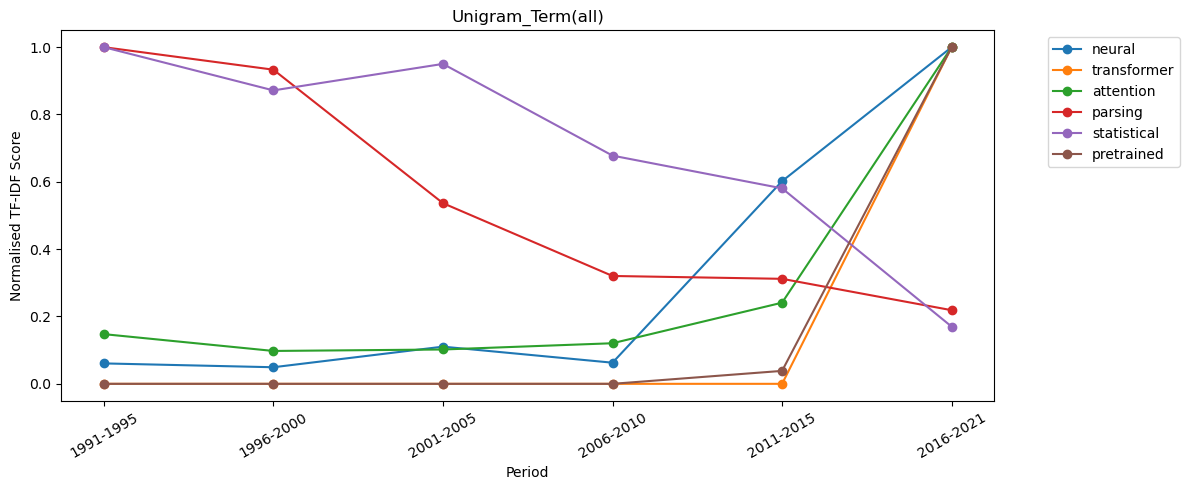

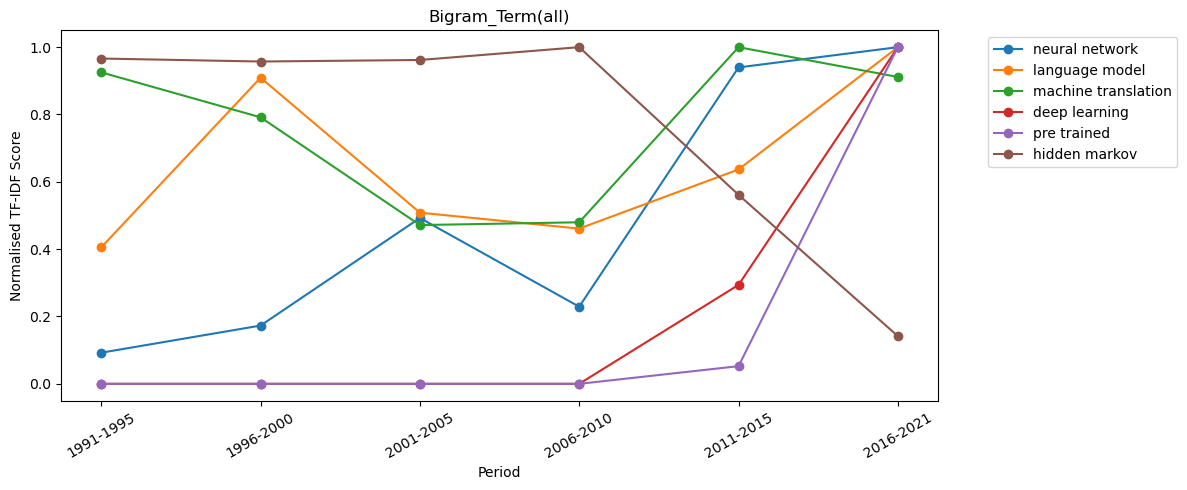

In [15]:
def plot_term_trends(matrix, vectorizer, df, terms, period_col="period", title=""):
    feat  = list(vectorizer.get_feature_names_out())
    periods = sorted(df[period_col].unique())
    valid = [t for t in terms if t in feat]
    if not valid:
        print("None specified terms")
        return

    scores = {t: [] for t in valid}
    for period in periods:
        mask = (df[period_col] == period).values
        # summed = np.asarray(matrix[mask].sum(axis=0)).flatten()
        summed = np.asarray(matrix[mask].mean(axis=0)).flatten()
        for t in valid:
            scores[t].append(summed[feat.index(t)])

    fig, ax = plt.subplots(figsize=(12, 5))
    for t, vals in scores.items():
        v = np.array(vals)
        if v.max() > 0:
            v = v / v.max()
        ax.plot(periods, v, marker="o", label=t)

    ax.set_title(title)
    ax.set_xlabel("Period")
    ax.set_ylabel("Normalised TF-IDF Score")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(f"../figures/{title.replace(' ', '_')}.png", dpi=150)
    plt.show()

unigram_track = ["neural", "transformer", "attention", "parsing", "statistical", "pretrained"]
plot_term_trends(uni_matrix, vectorizer_uni, df, unigram_track, title="Unigram_Term(all)")

bigram_track = ["neural network", "language model", "machine translation",
                "deep learning", "pre trained", "hidden markov"]
plot_term_trends(bi_matrix, vectorizer_bi, df, bigram_track, title="Bigram_Term(all)")



Based on the Unigram and Bigram timelines, we derived three key insights that perfectly illustrate the historic paradigm shift in NLP from the "Statistical Era" to the "Deep Learning Era":

#### 1. The "Death Cross" and Neural Dominance (Unigram)
* **The Exit of Statistical Methods**: The term `statistical`, representing traditional machine learning, dominated from the 1990s to the early 2000s but began an irreversible decline after 2010.
* **The Neural Takeover**: The trajectory of `neural` forms a perfect intersection with `statistical` between 2011 and 2015, marking the exact period when early neural networks began disrupting NLP.
* **The Large Model Explosion**: Most strikingly, `transformer`, `attention`, and `pretrained` were practically non-existent before 2015, but skyrocketed almost vertically between 2016 and 2021. This precisely aligns with the introduction of the Transformer architecture (2017) and pre-trained models like BERT (2018).

#### 2. The Fall of Classic Models and Paradigm Updates (Bigram)
* **The Twilight of Hidden Markov**: `hidden markov` maintained extreme popularity for two decades (1991-2010) as the backbone of sequence labeling. However, post-2010, it suffered a cliff-like drop, being entirely phased out by the deep learning boom.
* **The Rise of Pre-training**: Corresponding with the unigram trends, `language model` and `pre trained` strongly peaked in the last five years, indicating a fundamental shift from "task-specific model design" to the "pre-trained language model + fine-tuning" paradigm.

# Member 2 (XXX): XXXXX